# Full Comparison: Refiners x Template Models x Symmetry

This notebook performs a comprehensive comparison of different geometric refiners combined with different template parameterization models and symmetry settings.

**Refiners:**
*   `ContourRefiner`: Direct vertex optimization.
*   `BSplineContourRefiner`: Optimization of B-Spline control points.

**Template Models:**
*   `Fixed`: Constant parameters.
*   `Global`: Single learnable set of parameters.
*   `PerPoint`: Learnable parameters for each vertex.
*   `BSpline`: Spatially varying parameters (1D B-spline along contour).
*   `Neural`: Spatially varying parameters (2D Neural Field).
*   `Grid`: Spatially varying parameters (2D learnable grid).
*   `Splat`: Spatially varying parameters (Gaussian splatting).

**Symmetry:**
*   `Symmetric`: `sigma1` = `sigma2`, `amp1` = `amp2`.
*   `Asymmetric`: All parameters are independent.

In [7]:
%load_ext autoreload
%autoreload 2

import shutil
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from tqdm.notebook import tqdm

import diffmeshopt.opt2d.vis as vis2d
from diffmeshopt.opt2d.evaluation import compute_contour_metrics
from diffmeshopt.opt2d.optimize import BSplineContourRefiner, ContourRefiner
from diffmeshopt.opt2d.props import (
    BSplineContourRefinerProps,
    BSplineTemplateProps,
    ContourRefinerProps,
    GaussianSplatTemplateProps,
    GridTemplateProps,
    NeuralFieldTemplateProps,
    TemplateProps,
)
from diffmeshopt.opt2d.template import TemplateModelFactory
from diffmeshopt.opt2d.trainer import OptimizationTrainer, TrainerConfig, AtomicParquetLogger


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loading data from ../data/2d_training_data.pkl...


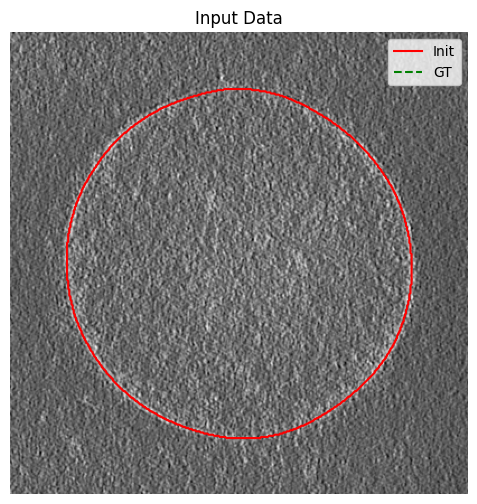

In [2]:
# 1. Load Data
data_path = Path("../data/2d_training_data.pkl")
if not data_path.exists():
    data_path = Path("/workspace/diffmeshopt/data/2d_training_data.pkl")

print(f"Loading data from {data_path}...")
data = joblib.load(data_path)
image_np = -data["image"]  # Invert intensity so membrane is dark
contour_np = data["contour"]
gt_contour_np = data["gt"]

plt.figure(figsize=(6, 6))
plt.imshow(image_np, cmap="gray")
plt.plot(contour_np[:, 1], contour_np[:, 0], "r-", label="Init")
plt.plot(gt_contour_np[:, 1], gt_contour_np[:, 0], "g--", label="GT")
plt.legend()
plt.title("Input Data")
plt.axis("off")
plt.show()

In [4]:
# 2. Define Experiment Configurations
refiners = ["Vertex", "BSpline"]
templates = ["fixed", "global", "per_point", "bspline", "neural", "grid", "splat"]
symmetries = [True, False]

experiments = []
for r in refiners:
    for t in templates:
        for s in symmetries:
            # 'fixed' and 'global' templates are the same for symmetric=True/False as they have no per-point ratio params
            if t in ["fixed", "global"] and s is False:
                continue
            experiments.append((r, t, s))

print(f"Defined {len(experiments)} experiments.")


def get_config(refiner_type, template_mode, symmetric, steps):
    # 1. Select Optimization Props based on Refiner
    if refiner_type == "BSpline":
        refiner_props = BSplineContourRefinerProps(
            num_steps=steps,
            learning_rate=0.05,
            laplacian_loss_weight=5.0,
            edge_length_loss_weight=1.0,
            contour_num_control_points=64,
            num_sampled_profiles=128,  # smaller batch size for performance
        )
        refiner_cls = BSplineContourRefiner
    else:  # Vertex
        refiner_props = ContourRefinerProps(
            num_steps=steps,
            learning_rate=0.05,
            laplacian_loss_weight=50.0,
            edge_length_loss_weight=10.0,
            num_sampled_profiles=128,
        )
        refiner_cls = ContourRefiner

    # 2. Select Template Props based on Mode
    template_props = TemplateProps(
        symmetric=symmetric,
    )

    if template_mode == "bspline":
        template_props = BSplineTemplateProps(
            **template_props.__dict__, bspline_num_control_points=8
        )
    elif template_mode == "neural":
        template_props = NeuralFieldTemplateProps(**template_props.__dict__, neural_hidden_dim=16)
        # Neural fields can be sensitive to high learning rates
        refiner_props.learning_rate = 0.01
    elif template_mode == "grid":
        template_props = GridTemplateProps(**template_props.__dict__, grid_size=8)
    elif template_mode == "splat":
        template_props = GaussianSplatTemplateProps(**template_props.__dict__, splat_num_splats=4)

    return refiner_cls, refiner_props, template_props

Defined 24 experiments.


In [9]:
device

'cpu'

In [8]:
# 3. Run Experiments
results = []
steps = 500
device = "cuda" if torch.cuda.is_available() else "cpu"

# Move data to device once
image_torch = torch.from_numpy(image_np).float().to(device)
contour_torch = torch.from_numpy(contour_np).float().to(device)
gt_contour_torch = torch.from_numpy(gt_contour_np).float().to(device)
img_shape = image_torch.shape

# Clean experiment directory
exp_dir = Path("../output/experiments/comparison/")
if exp_dir.exists():
    shutil.rmtree(exp_dir)

for refiner_name, template_mode, symmetric in tqdm(experiments, desc="All Experiments"):
    label = f"{refiner_name}_{template_mode}_{'sym' if symmetric else 'asym'}"
    print(f"Running: {label}")

    refiner_cls, refiner_props, template_props = get_config(
        refiner_name, template_mode, symmetric, steps
    )

    # Instantiate Template Model
    factory_kwargs = {
        "num_vertices": len(contour_torch),
        "image_shape": img_shape,
    }
    template_model = TemplateModelFactory.create(
        template_mode, props=template_props, **factory_kwargs
    ).to(device)

    # Instantiate Refiner
    refiner = refiner_cls(
        initial_contour=contour_torch.clone(),
        props=refiner_props,
        template_model=template_model,
    )

    # Train using OptimizationTrainer
    run_dir = exp_dir / label

    config = TrainerConfig(
        output_dir=run_dir,
        image=image_np,
        gt_contour=gt_contour_np,
        save_images=True,
        use_tensorboard=True,
        log_interval=10,
        save_interval=200,
        max_steps=steps,
    )

    trainer = OptimizationTrainer(refiner, config, run_dir=run_dir)
    trainer.fit(steps_to_run=steps)

    # Get metrics from logger history
    logger = next((l for l in trainer.trainer.loggers if isinstance(l, AtomicParquetLogger)), None)
    history = logger.history if logger else []
    loss_history = [h["total_loss"] for h in history if "total_loss" in h]
    final_loss = loss_history[-1] if loss_history else np.nan

    # Evaluate
    final_contour = refiner.contour.detach().cpu().numpy()
    geo_metrics = compute_contour_metrics(final_contour, gt_contour_np)

    # Store
    res_entry = {
        "Refiner": refiner_name,
        "Template": template_mode,
        "Symmetric": symmetric,
        "Label": label,
        "Final Loss": final_loss,
        "Mean Dist": geo_metrics.get("mean_dist", np.nan),
        "Hausdorff": geo_metrics.get("hausdorff_dist", np.nan),
        "Contour": final_contour,
        "Loss History": loss_history,
        "RefinerObj": refiner.cpu(),  # Move to CPU to free up GPU memory
    }
    results.append(res_entry)

All Experiments:   0%|          | 0/24 [00:00<?, ?it/s]

Running: Vertex_fixed_sym


/workspace/diffmeshopt/.pixi/envs/default/lib/python3.14/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /workspace/diffmeshopt/.pixi/envs/default/lib/python ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/diffmeshopt/output/experiments/comparison/Vertex_fixed_sym exists and is not empty.
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve perfo

Epoch 0: 100%|###| 500/500 [00:19<00:00, 26.23it/s, v_num=.0_0, total_loss=1.02]

`Trainer.fit` stopped: `max_steps=500` reached.


...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/diffmeshopt/output/experiments/comparison/Vertex_per_point_sym exists and is not empty.


Epoch 0:   8%|2  | 40/500 [00:01<00:18, 24.55it/s, v_num=.0_0, total_loss=0.995]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/workspace/diffmeshopt/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# 4. Quantitative Comparison (Table & Bar Plot)
df = pl.DataFrame(results)
display(df.select(["Refiner", "Template", "Symmetric", "Mean Dist", "Hausdorff", "Final Loss"]).sort(["Refiner", "Template", "Symmetric"]))

# Bar plot using matplotlib
templates = sorted(df["Template"].unique().to_list())
refiners = sorted(df["Refiner"].unique().to_list())
symmetries = [True, False]

# Create a subplot for each refiner
fig, axes = plt.subplots(1, len(refiners), figsize=(8 * len(refiners), 5), sharey=True)
if len(refiners) == 1: axes = [axes]

for i, refiner in enumerate(refiners):
    ax = axes[i]
    subset = df.filter(pl.col("Refiner") == refiner)
    
    x = np.arange(len(templates))
    width = 0.35
    
    # Symmetric bars
    sym_true_map = {row["Template"]: row["Mean Dist"] for row in subset.filter(pl.col("Symmetric") == True).iter_rows(named=True)}
    sym_true_vals = [sym_true_map.get(t, 0) for t in templates]
    ax.bar(x - width/2, sym_true_vals, width, label='Symmetric')

    # Asymmetric bars
    sym_false_map = {row["Template"]: row["Mean Dist"] for row in subset.filter(pl.col("Symmetric") == False).iter_rows(named=True)}
    sym_false_vals = [sym_false_map.get(t, 0) for t in templates]
    ax.bar(x + width/2, sym_false_vals, width, label='Asymmetric')

ax.set_ylabel("Mean Distance (Pixels)")
ax.set_title(f"Refiner: {refiner}")
ax.set_xticks(x)
ax.set_xticklabels(templates, rotation=45, ha="right")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Mean Distance to GT by Configuration", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# 5. Qualitative Comparison (Contours)
cols = 4
rows = (len(results) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = axes.flatten()

for i, res in enumerate(results):
    ax = axes[i]
    ax.imshow(image_np, cmap="gray")
    ax.plot(gt_contour_np[:, 1], gt_contour_np[:, 0], "g--", alpha=0.5, label="GT")
    ax.plot(res["Contour"][:, 1], res["Contour"][:, 0], "r-", linewidth=1.5, label="Pred")
    ax.set_title(f"{res['Label']}\nDist: {res['Mean Dist']:.2f}")
    ax.axis("off")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 6. Visualize Learned Template Parameters
for res in results:
    # Only plot for optimizable, non-fixed models
    if res["Template"] not in ["fixed"]:
        refiner = res["RefinerObj"]
        # get_params needs coordinates, use the final contour
        final_contour_torch = torch.from_numpy(res["Contour"]).to(device)
        params = refiner.template_model.get_params(coordinates=final_contour_torch)
        
        plt.figure(figsize=(10, 3))
        vis2d.plot_parameter_curves(params, ax=plt.gca())
        plt.title(f"Learned Parameters: {res['Label']}")
        plt.show()